# ECG image digitisation with classical image processing

Own-code solution for the Kaggle competition PhysioNet - Digitization of ECG Images. A photo or scan of a 12-lead ECG goes in, the twelve signals in mV come out. Only OpenCV, NumPy and SciPy are used: no neural network and no pretrained weights.

This is the baseline for my submitted notebook, which runs pretrained models from other competitors (hengck23 and Takashi Someya). The notebook:

- digitises a local benchmark of 48 ECG images and scores them with the competition's SNR metric,
- switches single steps off to see what each one is worth,
- compares with the scores of the pretrained pipeline on the same images,
- scores training ECGs and writes `submission.csv` when the competition data is attached.

Benchmark numbers come from synthetic images and are not leaderboard scores. The Kaggle score is in the last cell.

In [1]:
import os, sys, time, json, csv
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi, signal as sps
from IPython.display import display

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': False, 'font.size': 9})

## Inputs

The benchmark folder (images, PTB-XL records, scores of the pretrained pipeline) is searched next to the notebook and in `/kaggle/input`. Without it the benchmark sections are skipped. The competition data is optional too: without it only the benchmark runs.

In [2]:
CONFIG = dict(
    benchmark_dir=None,        # None: search ../benchmark, ./benchmark and /kaggle/input
    competition_dir=None,      # None: search /kaggle/input for a folder with test.csv and test/
    n_check=20,                # training ECGs of the competition scored in the last section
    images_per_check=3,        # image types per training ECG
    submission_path='submission.csv',
    workers=min(4, os.cpu_count() or 1),
)


def locate(markers, roots, max_depth=4, hint=''):
    """First folder below `roots` that contains all `markers` (shallowest first, `hint` in the path preferred)."""
    found, queue = [], [(Path(r), 0) for r in roots]
    while queue:
        folder, depth = queue.pop(0)
        try:
            entries = {e.name: e.is_dir() for e in os.scandir(folder)}
        except OSError:
            continue
        if all(m in entries for m in markers):
            found.append(folder)
        elif depth < max_depth:
            queue += [(folder / n, depth + 1) for n, is_dir in sorted(entries.items())
                      if is_dir and n not in ('train', 'test', 'images', 'records')]
    return min(found, key=lambda p: (len(p.parts), hint not in str(p).lower()), default=None)


BENCH = Path(CONFIG['benchmark_dir']) if CONFIG['benchmark_dir'] else \
    locate(['images', 'records'], [Path('..'), Path('.'), Path('/kaggle/input')], hint='benchmark')
COMP = Path(CONFIG['competition_dir']) if CONFIG['competition_dir'] else \
    locate(['test.csv', 'test'], [Path('/kaggle/input')], hint='ecg')
print('benchmark  :', BENCH)
print('competition:', COMP if COMP else 'not attached')
if BENCH is None:
    print('benchmark folder not found: the benchmark sections are skipped, only the competition section runs')

benchmark  : ../benchmark
competition: not attached


## Benchmark

- **Signals:** PTB-XL records 00001 to 00016 (500 Hz, 10 s, 12 leads, CC BY 4.0).
- **Images:** each record drawn with ecg-image-kit (BSD-3-Clause) at 200 dpi in the competition layout: three rows of four leads (2.5 s each), a 10 s lead II rhythm strip, calibration pulse and red grid. These are clean renders, so they are easier than real scans and photos.
- **Development set:** records 1 to 8. Thresholds and the apex factor were chosen while looking at them.
- **Held-out set:** records 9 to 16, rendered after the code was finished. No threshold or tuning factor was changed after their scores were first looked at. One later change, making the tilt estimate independent of the image size (needed for the size test below), moved six tilt4 scores by at most 0.13 dB.
- **Distorted copies:** four records of each set, made by the functions below (deterministic):

| variant | what it does |
|---|---|
| `tilt4` | page rotated by 4 degrees, corners cut off |
| `persp` | page photographed from the side: perspective warp, whole page in the frame, grey background |
| `degraded` | blur, lower contrast, noise and JPEG quality 40 |
| `rot90`, `rot180` | page turned by 90 or 180 degrees |

The truth is the PTB-XL signal. A lead in a row of four holds 2.5 s, lead II holds the whole 10 s.

In [3]:
if BENCH is not None:
    def read_record(path):
        """Read a WFDB record (16-bit PTB-XL files). Returns {lead: signal in mV} and the sampling rate."""
        lines = Path(str(path) + '.hea').read_text().splitlines()
        _, n_sig, fs, n_samples = lines[0].split()[:4]
        n_sig, n_samples = int(n_sig), int(n_samples)
        sigs = [l.split() for l in lines[1:1 + n_sig]]
        raw = np.fromfile(str(path) + '.dat', dtype='<i2').reshape(n_samples, n_sig).astype(np.float64)
        gain = np.array([float(s[2].split('(')[0].split('/')[0]) for s in sigs])
        zero = np.array([float(s[4]) for s in sigs])
        rename = {'AVR': 'aVR', 'AVL': 'aVL', 'AVF': 'aVF'}
        return {rename.get(s[-1], s[-1]): (raw[:, i] - zero[i]) / gain[i] for i, s in enumerate(sigs)}, float(fs)


    def competition_truth(sig):
        """Truth in the competition layout: short leads cover their 2.5 s block, lead II the full 10 s."""
        n = len(sig['I'])
        truth = {k: sig[k][j * n // 4:(j + 1) * n // 4] for names in LAYOUT for j, k in enumerate(names)}
        truth['II'] = sig['II']
        return truth


    def persp(im):
        """Photo from slightly off axis: perspective warp, the whole page stays in the frame."""
        h, w = im.shape[:2]
        src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
        dst = np.float32([[0.08 * w, 0.07 * h], [0.93 * w, 0.03 * h], [0.97 * w, 0.94 * h], [0.03 * w, 0.97 * h]])
        return cv2.warpPerspective(im, cv2.getPerspectiveTransform(src, dst), (w, h),
                                   borderMode=cv2.BORDER_CONSTANT, borderValue=(235, 235, 235))


    def rot_small(im, deg=4.0):
        h, w = im.shape[:2]
        M = cv2.getRotationMatrix2D((w / 2, h / 2), deg, 1.0)
        return cv2.warpAffine(im, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(240, 240, 240))


    def degrade(im):
        rng = np.random.default_rng(0)
        out = cv2.GaussianBlur(im, (0, 0), 1.2).astype(np.float32)
        out = np.clip(out * 0.85 + 20 + rng.normal(0, 6, out.shape), 0, 255).astype(np.uint8)
        ok, enc = cv2.imencode('.jpg', cv2.cvtColor(out, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, 40])
        return cv2.cvtColor(cv2.imdecode(enc, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)


    def make_variant(img, variant):
        return {'clean': lambda im: im, 'tilt4': rot_small, 'persp': persp, 'degraded': degrade,
                'rot90': lambda im: cv2.rotate(im, cv2.ROTATE_90_CLOCKWISE),
                'rot180': lambda im: cv2.rotate(im, cv2.ROTATE_180)}[variant](img)


    DEV = [f'{i:05d}' for i in range(1, 9)]
    HELD = [f'{i:05d}' for i in range(9, 17)]
    MANIFEST = []                      # (name, record, variant, subset)
    for subset, records in (('dev', DEV), ('held', HELD)):
        MANIFEST += [(f'{r}_clean', r, 'clean', subset) for r in records]
        for v in ('tilt4', 'persp', 'degraded') + (('rot90', 'rot180') if subset == 'dev' else ()):
            MANIFEST += [(f'{r}_{v}', r, v, subset) for r in records[:4]]


    def load_item(rec, variant):
        img = make_variant(read_rgb(BENCH / 'images' / f'{rec}_hr-0.png'), variant)
        sig, fs = read_record(BENCH / 'records' / f'{rec}_hr')
        truth = competition_truth(sig)
        n_rows = {k: len(v) for k, v in truth.items()}
        return img, truth, n_rows, fs


    print(len(MANIFEST), 'benchmark images:', pd.Series([m[3] + ' ' + m[2] for m in MANIFEST]).value_counts().to_dict())

48 benchmark images: {'dev clean': 8, 'held clean': 8, 'dev tilt4': 4, 'dev persp': 4, 'dev rot90': 4, 'dev degraded': 4, 'dev rot180': 4, 'held tilt4': 4, 'held persp': 4, 'held degraded': 4}


## Metric

`snr_ecg` approximates the competition metric: per ECG, signal power over error power in dB, summed over the 12 leads. Each lead may be shifted by up to 0.2 s (best cross-correlation) and its constant offset is removed. It is not the official code, so small differences are possible. The pretrained pipeline was scored with the same function.

`split_leads` cuts the four digitised rows into the 12 leads. The first block of the middle row is the start of the rhythm strip, so its length is the lead II length minus the other three blocks.

In [4]:
LAYOUT = [['I', 'aVR', 'V1', 'V4'], ['II', 'aVL', 'V2', 'V5'], ['III', 'aVF', 'V3', 'V6']]
LEADS = [k for names in LAYOUT for k in names]
PAPER_SPEED = 25.0       # mm per second
GAIN = 10.0              # mm per mV
STRIP_SECONDS = 10.0     # every strip on the page covers 10 s
INK_THR = 0.5            # ink map level that counts as trace
MIN_PPM = 6.5            # images with fewer pixels per mm than this are enlarged first

In [5]:
def snr_ecg(truth, pred, fs, max_shift_s=0.2):
    """Approximation of the competition metric: signal power over error power, summed over the 12 leads.

    Per lead the prediction may be shifted by up to 0.2 s (best shift by cross-correlation) and a constant
    offset is removed before the error is measured. The result is in dB.
    """
    max_shift = int(round(max_shift_s * fs))
    signal_power = noise_power = 0.0
    for lead, t in truth.items():
        p = pred[lead]
        n = min(len(t), len(p))
        t, p = np.nan_to_num(t[:n]), p[:n]
        best_lag, best_corr = 0, -np.inf
        for lag in range(-max_shift, max_shift + 1):
            a0, a1 = max(0, lag), min(n, n + lag)
            if a1 - a0 < 10:
                continue
            ta, pa = t[a0:a1], p[a0 - lag:a1 - lag]
            corr = np.dot(ta - ta.mean(), pa - pa.mean())
            if corr > best_corr:
                best_lag, best_corr = lag, corr
        a0, a1 = max(0, best_lag), min(n, n + best_lag)
        ta, pa = t[a0:a1], p[a0 - best_lag:a1 - best_lag]
        offset = np.mean(ta - pa)
        signal_power += np.sum(ta ** 2)
        noise_power += np.sum((ta - pa - offset) ** 2)
    return 10 * np.log10(signal_power / max(noise_power, 1e-12))


def split_leads(series, n_rows):
    """(4, T) series -> dict lead -> signal. Rows 0-2 hold four leads each, row 3 is the lead II rhythm strip."""
    leads = {}
    for r, names in enumerate(LAYOUT):
        sizes = [int(n_rows[k]) for k in names]
        if names[0] == 'II':
            sizes[0] = max(0, sizes[0] - sum(sizes[1:]))     # the first block of row 2 is the start of lead II
        for k, piece in zip(names, np.split(series[r], np.cumsum(sizes)[:-1])):
            leads[k] = piece
    leads['II'] = series[3]
    return leads

## Method

The paper grid is 1 mm and 5 mm, the speed is 25 mm/s and the gain 10 mm/mV. Once the grid spacing in pixels is known, every pixel is a time and a voltage.

1. **Ink and grid maps.** The trace and text are dark in every colour channel, the grid is red.
2. **Page geometry.** The page is found from the grid and warped to a rectangle, the remaining tilt is removed, and the page is turned until the strips run left to right with the 10 mm calibration pulse on the left.
3. **Scale.** The spacing of the 5 mm lines is fitted over the whole page with a comb fit. On the 16 clean renders it is within 0.03 % of the true value.
4. **Strips.** Four peaks in the row profile of the ink are the four baselines. The last ink column is the end of the 10 s window, 250 mm to its left is the start.
5. **Trace.** In every pixel column the ink forms runs. Dynamic programming picks one run per column and strip so that the path is continuous. The value of a run is its ink-weighted centre.
6. **Signal.** The centres are sampled at the output times and converted to mV. At narrow spikes the value is moved towards the end of the run, because the centre of a run underestimates a spike.

Each step is one cell below. The ablation table later switches steps off.

### 1. Ink and grid maps

In [6]:
def read_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f'cannot read {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def ink_and_grid(img):
    """Two float maps in [0, 1]: ink (black trace and text) and grid (red or pink paper grid)."""
    rgb = img.astype(np.float32)
    mx = rgb.max(2)                                      # dark in every channel = ink, red has a high R channel
    bg, fg = np.percentile(mx, 70), np.percentile(mx, 0.1)
    ink = np.clip((bg - mx) / max(bg - fg, 1.0), 0, 1)
    red = rgb[..., 0] - 0.5 * (rgb[..., 1] + rgb[..., 2])
    grid = np.clip(red / max(np.percentile(red, 99.5), 1.0), 0, 1)
    grid[ink > 0.4] = 0
    for m in (ink, grid):                                # scanner borders
        m[:3], m[-3:], m[:, :3], m[:, -3:] = 0, 0, 0, 0
    if grid.mean() < 0.01:
        raise ValueError('no coloured grid found')
    return ink, grid

### 2. Page geometry

`rectify_page` removes perspective, `rotate_map` removes the remaining tilt, `drop_page_edge` erases frame lines and the table around the page, `upright` handles 90 and 180 degree turns, and `grid_pitch` returns the spacing of the 5 mm lines.

In [7]:
def page_quad(grid):
    """Corners (tl, tr, br, bl) of the printed page, found from the area covered by the paper grid."""
    s = 0.25
    g = cv2.resize(((grid > 0.005) * 255).astype(np.uint8), None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    g = cv2.morphologyEx((g > 90).astype(np.uint8), cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    cnts, _ = cv2.findContours(g, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(c) < 0.25 * g.size:
        return None
    hull = cv2.convexHull(c)
    peri = cv2.arcLength(hull, True)
    for eps in np.linspace(0.01, 0.1, 19):
        approx = cv2.approxPolyDP(hull, eps * peri, True)
        if len(approx) == 4:
            break
    else:
        return None
    p = approx[:, 0, :].astype(np.float32) / s
    tl, br = p[np.argmin(p.sum(1))], p[np.argmax(p.sum(1))]
    tr, bl = p[np.argmin(p[:, 1] - p[:, 0])], p[np.argmax(p[:, 1] - p[:, 0])]
    return np.stack([tl, tr, br, bl])


def rectify_page(ink, grid, tol=3.0):
    """Perspective correction: warp both maps so that the page quadrilateral becomes an upright rectangle."""
    q = page_quad(grid)
    if q is None:
        return ink, grid
    tl, tr, br, bl = q
    W = int(round(max(np.linalg.norm(tr - tl), np.linalg.norm(br - bl))))
    H = int(round(max(np.linalg.norm(bl - tl), np.linalg.norm(br - tr))))
    if min(W, H) < 0.25 * min(grid.shape) or not (0.5 < W / H < 2.0):
        return ink, grid
    box = np.array([[q[:, 0].min(), q[:, 1].min()], [q[:, 0].max(), q[:, 1].min()],
                    [q[:, 0].max(), q[:, 1].max()], [q[:, 0].min(), q[:, 1].max()]])
    if np.abs(q - box).max() < tol:
        return ink, grid                                 # already an upright rectangle, nothing to correct
    M = cv2.getPerspectiveTransform(q, np.float32([[0, 0], [W - 1, 0], [W - 1, H - 1], [0, H - 1]]))
    return (cv2.warpPerspective(ink, M, (W, H), flags=cv2.INTER_LINEAR),
            cv2.warpPerspective(grid, M, (W, H), flags=cv2.INTER_LINEAR))


def tilt_degrees(grid):
    """Tilt of the grid in degrees (clockwise positive, -45..45) from the gradient directions modulo 90 degrees."""
    f = 1100.0 / max(grid.shape)                        # work at the same scale for any image size (0.5 for 2200 px)
    g = cv2.GaussianBlur(cv2.resize(grid, None, fx=f, fy=f, interpolation=cv2.INTER_AREA), (0, 0), 2.0)
    gx, gy = cv2.Scharr(g, cv2.CV_32F, 1, 0), cv2.Scharr(g, cv2.CV_32F, 0, 1)
    z = (np.hypot(gx, gy) * np.exp(4j * np.arctan2(gy, gx))).sum()      # angle * 4 makes 90 degrees a full turn
    return float(np.degrees(np.angle(z)) / 4)


def rotate_map(m, deg):
    """Rotate a map counter-clockwise by `deg` on an enlarged canvas, zero fill."""
    h, w = m.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), deg, 1.0)
    c, s = abs(M[0, 0]), abs(M[0, 1])
    nw, nh = int(round(h * s + w * c)), int(round(h * c + w * s))
    M[0, 2] += nw / 2 - w / 2
    M[1, 2] += nh / 2 - h / 2
    return cv2.warpAffine(m, M, (nw, nh), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)


def drop_page_edge(ink, grid, margin=8):
    """Erase ink within `margin` px of the page edge: frame lines, page border, table."""
    xs, ys = np.flatnonzero(grid.sum(0) > 20), np.flatnonzero(grid.sum(1) > 20)
    if len(xs) < 10 or len(ys) < 10:
        return ink
    out = np.zeros_like(ink)
    y0, y1, x0, x1 = ys[0] + margin, ys[-1] - margin + 1, xs[0] + margin, xs[-1] - margin + 1
    out[y0:y1, x0:x1] = ink[y0:y1, x0:x1]
    return out


def grid_pitch(grid, axis, width_mm=(180.0, 800.0)):
    """Spacing of the 5 mm grid lines in pixels along one axis, fitted over the whole page.

    axis=0 sums over rows (spacing along x), axis=1 sums over columns (spacing along y). The page is assumed to
    be between 180 and 800 mm wide in the image, which limits the search range for the first guess.
    """
    prof = grid.sum(axis=axis).astype(np.float64)
    n = len(prof)
    prof = prof - ndi.gaussian_filter1d(prof, 60.0)
    f = np.fft.rfft(prof, 2 * n)
    acf = np.fft.irfft(f * np.conj(f))[:n]              # autocorrelation: first guess from the strongest lag
    lo, hi = max(max(grid.shape) / width_mm[1] * 5.0, 8.0), min(max(grid.shape) / width_mm[0] * 5.0, n / 3)
    lags = np.arange(int(lo), int(hi) + 1)
    p0 = float(lags[np.argmax(acf[lags])])
    sm = ndi.gaussian_filter1d(prof, 1.0)
    xs = np.arange(n)

    def comb(P, phases=48):                             # how much line energy sits on a lattice with spacing P
        k = np.arange(0, int((n - 1) / P))
        return max(np.interp(ph + k * P, xs, sm).sum() for ph in np.linspace(0, P, phases, endpoint=False))

    for span, steps in ((0.03, 61), (0.003, 31), (0.0004, 21)):     # coarse to fine
        cands = p0 * (1 + np.linspace(-span, span, steps))
        p0 = float(cands[int(np.argmax([comb(P) for P in cands]))])
    return p0

### 3. Orientation and strips

Strips are horizontal, so for the right orientation the row profile of the ink varies more than the column profile. The 180 degree case is decided by the calibration pulse: it is 10 mm tall, much taller than the end of the trace, and sits at the left end of every strip.

In [8]:
def horizontal_runs(B, length):
    return cv2.morphologyEx(B, cv2.MORPH_OPEN, np.ones((1, max(int(length), 1)), np.uint8))


def find_strips(B, ppm, n_strips=4):
    """Baseline rows (px) of the four strips: peaks of the row profile of short horizontal ink runs."""
    prof = ndi.gaussian_filter1d(horizontal_runs(B, 1.0 * ppm).sum(1).astype(np.float64), 1.5 * ppm)
    for rel in (0.2, 0.05):
        peaks, _ = sps.find_peaks(prof, distance=int(15 * ppm), height=rel * prof.max())
        if len(peaks) >= n_strips:
            return np.sort(peaks[np.argsort(prof[peaks])[::-1][:n_strips]]).astype(float)
    return None


def pulse_score(B, ppm, rows):
    """Vertical extent of the ink at the left end of each strip minus the right end, in mm (median over strips).

    The calibration pulse is 10 mm tall and sits at the left end of every strip, so the score is positive when
    the page is the right way up.
    """
    H = horizontal_runs(B, 1.0 * ppm)
    half, out = int(14 * ppm), []
    for r in rows:
        a, b = int(max(r - half, 0)), int(min(r + half, B.shape[0]))
        cols = np.flatnonzero(H[a:b].sum(0) > 0)
        if len(cols) < 10:
            continue
        ext = []
        for side, c in enumerate((cols[0], cols[-1])):
            sl = B[a:b, max(c - 1, 0):c + 3] if side == 0 else B[a:b, max(c - 3, 0):c + 1]
            ys = np.flatnonzero(sl.any(1))
            ext.append((ys.max() - ys.min()) / ppm if len(ys) else 0.0)
        out.append(ext[0] - ext[1])
    return float(np.median(out)) if out else 0.0


def upright(ink, grid):
    """Turn both maps by a multiple of 90 degrees so that the strips run left to right with the pulse on the left."""
    B = (ink > INK_THR).astype(np.uint8)
    ppm = grid_pitch(grid, 0) / 5.0
    # strips are horizontal bands: the row profile of the ink varies more than the column profile
    horizontal = (ndi.gaussian_filter1d(B.sum(1).astype(float), 2 * ppm).std()
                  >= ndi.gaussian_filter1d(B.sum(0).astype(float), 2 * ppm).std())
    if not horizontal:
        ink, grid = np.rot90(ink).copy(), np.rot90(grid).copy()
    B = (ink > INK_THR).astype(np.uint8)
    rows = find_strips(B, grid_pitch(grid, 0) / 5.0)
    if rows is not None and pulse_score(B, grid_pitch(grid, 0) / 5.0, rows) < 0:
        ink, grid = np.rot90(ink, 2).copy(), np.rot90(grid, 2).copy()
    return ink, grid

### 4. Trace extraction

`column_runs` lists the ink runs of every column and `track_strip` picks one run per column with dynamic programming. A step between two runs costs their vertical gap in mm (zero when they touch), a skipped column costs 0.5, and a run far from the strip baseline pays a small price. This keeps the path on its own strip where strokes of neighbouring leads cross it, and lets it skip text that touches the trace.

In [9]:
def column_runs(B, ink):
    """For every pixel column the runs of ink pixels: start, end (exclusive) and ink-weighted centre."""
    H, W = B.shape
    wsum = np.cumsum(np.vstack([np.zeros((1, W), np.float32), ink]), axis=0)
    ysum = np.cumsum(np.vstack([np.zeros((1, W), np.float32), ink * np.arange(H, dtype=np.float32)[:, None]]), axis=0)
    out = []
    for x in range(W):
        d = np.diff(np.concatenate([[0], B[:, x], [0]]))
        s, e = np.flatnonzero(d == 1), np.flatnonzero(d == -1)
        if len(s) == 0:
            out.append((s, e, np.zeros(0)))
            continue
        s2, e2 = np.maximum(s - 1, 0), np.minimum(e + 1, H)      # include the soft edge pixels
        w = wsum[e2, x] - wsum[s2, x]
        out.append((s, e, (ysum[e2, x] - ysum[s2, x]) / np.maximum(w, 1e-6)))
    return out


def track_strip(runs, x0, x1, base, span, ppm, blocked=None, skip=0.5, prior=0.03, look=3):
    """Cheapest path through the column runs of one strip (dynamic programming).

    Nodes are the ink runs of a column inside the strip window. A step costs the vertical gap between two runs
    in mm (zero if they touch) plus `skip` for every column that is left out, and every run pays `prior` per mm
    for lying away from the strip baseline. Columns in `blocked` have no nodes, so the path bridges them.
    Returns (start, end, centre) per column, NaN where the path skips a column.
    """
    lo, hi = base - span, base + span
    cols = []
    for x in range(x0, x1):
        if blocked is not None and blocked[x]:
            continue
        s, e, c = runs[x]
        keep = (e > lo) & (s < hi)
        if keep.any():
            cols.append((x, s[keep].astype(float), e[keep].astype(float), c[keep]))
    cost, back = [], []
    for i, (x, s, e, c) in enumerate(cols):
        cur = prior * np.abs(c - base) / ppm + skip * (x - x0)          # start of the path
        arg = np.full((len(s), 2), -1, dtype=int)
        for L in range(1, look + 1):
            if i - L < 0:
                break
            xp, ps, pe, pc = cols[i - L]
            g = x - xp
            gap = np.maximum(0, np.maximum(s[:, None] - pe[None, :], ps[None, :] - e[:, None])) / ppm
            trans = gap / np.sqrt(g) + 0.05 * np.abs(c[:, None] - pc[None, :]) / ppm + skip * (g - 1)
            tot = trans + cost[i - L][None, :]
            j = np.argmin(tot, axis=1)
            val = tot[np.arange(len(s)), j] + prior * np.abs(c - base) / ppm
            better = val < cur
            cur = np.where(better, val, cur)
            arg[better] = np.stack([np.full(better.sum(), i - L), j[better]], axis=1)
        cost.append(cur)
        back.append(arg)
    path = np.full((x1 - x0, 3), np.nan)
    if not cols:
        return path
    best, bi, bj = np.inf, -1, -1
    for i in range(max(0, len(cols) - look), len(cols)):
        v = cost[i] + skip * (x1 - 1 - cols[i][0])
        j = int(np.argmin(v))
        if v[j] < best:
            best, bi, bj = v[j], i, j
    while bi >= 0:
        x, s, e, c = cols[bi]
        path[x - x0] = (s[bj], e[bj], c[bj])
        bi, bj = back[bi][bj]
    return path

### 5. Signal

`strip_to_mv` samples the path at the output times. `apex_adjust` corrects spikes: at a narrow R or S wave the centre of the run lies half way along the stroke, but the true apex is at the end of it.

In [10]:
def apex_adjust(path, thin, frac):
    """Centre of every tracked run, moved towards the far end of the run where the trace turns (spike apex).

    The centre of mass underestimates narrow QRS spikes because the up and down stroke fall into the same pixel
    columns. If a run is longer than `thin` and its centre is a local extremum of the centre sequence, the value
    moves a fraction `frac` of the way to the end of the run that lies in the direction of the turn.
    """
    s, e, c = path[:, 0], path[:, 1] - 1.0, path[:, 2].copy()
    out = c.copy()
    idx = np.flatnonzero(~np.isnan(c))
    for pos in range(1, len(idx) - 1):
        i, p, q = idx[pos], idx[pos - 1], idx[pos + 1]
        if e[i] - s[i] <= thin:
            continue
        d1, d2 = c[i] - c[p], c[i] - c[q]
        if d1 < 0 and d2 < 0:             # image y points down: a local minimum of y is a peak pointing up
            out[i] = c[i] + frac * (s[i] - c[i])
        elif d1 > 0 and d2 > 0:           # a local maximum of y is a trough
            out[i] = c[i] + frac * (e[i] - c[i])
    return out


def fill_gaps(y):
    ok = ~np.isnan(y)
    if ok.sum() < 2:
        return np.zeros_like(y)
    idx = np.arange(len(y))
    return np.interp(idx, idx[ok], y[ok])


def strip_to_mv(path, x0, x_start, ppm_x, ppm_y, base, length, apex_frac=0.6, apex_thin_mm=1.5):
    """Sample one tracked strip at `length` points over 10 s and convert pixels to mV (1 mV = 10 mm)."""
    c = apex_adjust(path, apex_thin_mm * ppm_x, apex_frac) if apex_frac > 0 else path[:, 2]
    y = fill_gaps(c)
    t = (np.arange(length) + 0.5) / length * STRIP_SECONDS
    val = np.interp(x_start + t * PAPER_SPEED * ppm_x, np.arange(len(y)) + x0 + 0.5, y)
    return ((base - val) / (GAIN * ppm_y)).astype(np.float32)

### Lead tick experiment

A thick tick is printed at the start of every lead and can touch the trace. This experiment deletes it and lets the path bridge the gap. It is off by default because it did not help (see ablations).

In [11]:
def remove_boundary_bars(ink, x_start, ppm_x, ppm_y):
    """Experiment: delete the thick vertical tick printed at the start of each lead (at 2.5, 5 and 7.5 s)."""
    B = (ink > INK_THR).astype(np.uint8)
    w, h = max(3, int(round(0.5 * ppm_x))), max(3, int(round(3 * ppm_y)))
    opened = cv2.morphologyEx(B, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (w, h)))
    near = np.zeros(B.shape[1], bool)
    for j in (1, 2, 3):
        xb = x_start + j * 2.5 * PAPER_SPEED * ppm_x
        near[max(int(xb - 1.5 * ppm_x), 0):int(xb + 1.5 * ppm_x) + 1] = True
    bars = cv2.dilate(opened * near[None, :].astype(np.uint8), np.ones((1, 3), np.uint8))
    ink = ink.copy()
    ink[bars > 0] = 0
    return ink, bars.any(0)

### The complete function

In [12]:
def digitize(img, length=5000, info=None, rectify=True, tilt=True, apex_frac=0.6, bars=False):
    """ECG page image -> (4, length) series in mV: three rows of four leads and the lead II rhythm strip.

    rectify, tilt, apex_frac and bars switch single steps on or off for the ablation table.
    If `info` is a dict it receives the intermediate results for plotting.
    """
    ink, grid = ink_and_grid(img)
    if rectify:
        ink, grid = rectify_page(ink, grid)
    if tilt:
        deg = tilt_degrees(grid)
        if abs(deg) > 0.05:
            ink, grid = rotate_map(ink, deg), rotate_map(grid, deg)
    ink = drop_page_edge(ink, grid)
    ppm0 = grid_pitch(grid, 0) / 5.0
    if ppm0 < MIN_PPM:                                         # low resolution: enlarge the maps to about 7.9 px/mm
        f = 7.87 / ppm0
        ink, grid = (cv2.resize(m, None, fx=f, fy=f, interpolation=cv2.INTER_CUBIC) for m in (ink, grid))
        ink, grid = np.clip(ink, 0, 1), np.clip(grid, 0, 1)
    ink, grid = upright(ink, grid)
    B = (ink > INK_THR).astype(np.uint8)
    ppm_x, ppm_y = grid_pitch(grid, 0) / 5.0, grid_pitch(grid, 1) / 5.0
    ppm = 0.5 * (ppm_x + ppm_y)
    rows = find_strips(B, ppm)
    if rows is None:
        raise ValueError('four strips not found')
    H = horizontal_runs(B, 1.0 * ppm)
    last = [np.flatnonzero(H[int(r - 14 * ppm):int(r + 14 * ppm)].sum(0) > 0) for r in rows]
    x_end = float(np.median([c[-1] + 1 for c in last if len(c)]))
    x_start = x_end - STRIP_SECONDS * PAPER_SPEED * ppm_x          # 10 s = 250 mm to the left of the last column
    blocked = None
    if bars:
        ink, blocked = remove_boundary_bars(ink, x_start, ppm_x, ppm_y)
        B = (ink > INK_THR).astype(np.uint8)
    x0, x1 = max(int(x_start) - 2, 0), min(int(x_end) + 2, B.shape[1])
    runs = column_runs(B, ink)
    guard = int(np.ceil(x_start + 0.6 * ppm_x)) - x0              # the right edge of the calibration pulse touches x_start
    spacing = float(np.median(np.diff(rows)))
    series, paths = [], []
    for r in rows:
        path = track_strip(runs, x0, x1, r, spacing, ppm, blocked=blocked)
        path[:max(guard, 0)] = np.nan
        paths.append(path)
        series.append(strip_to_mv(path, x0, x_start, ppm_x, ppm_y, r, length, apex_frac))
    if info is not None:
        info.update(ink=ink, grid=grid, rows=rows, x_start=x_start, x_end=x_end, x0=x0,
                    ppm_x=ppm_x, ppm_y=ppm_y, paths=paths)
    return np.stack(series)


def digitize_safe(img, length=5000, **kw):
    """Same as digitize, but a failure returns an all-zero series and the error text instead of raising."""
    try:
        return digitize(img, length, **kw), None
    except Exception as exc:
        return np.zeros((4, length), np.float32), f'{type(exc).__name__}: {exc}'

## One image, step by step

A perspective-distorted copy of record 00001: the original, the two maps, and the page after rectification, tilt correction and turning, with the detected strips and the 10 s window.

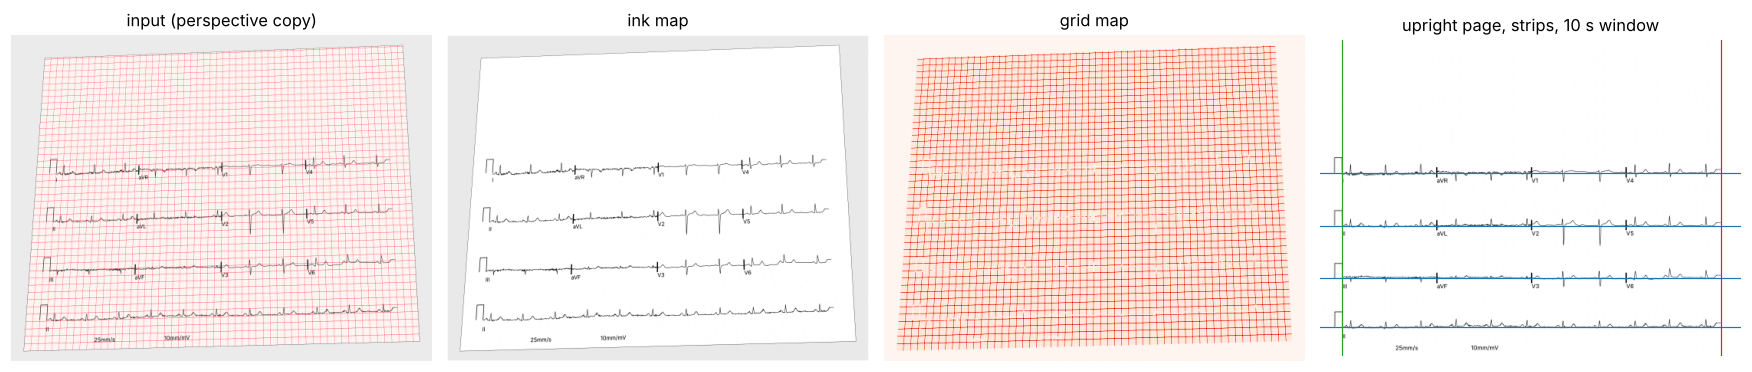

grid spacing: 7.406 px/mm along x, 7.179 px/mm along y (rectified page)
baseline rows: [647, 905, 1160, 1400]  10 s window from column 108 to 1960


In [13]:
if BENCH is not None:
    img, truth, n_rows, fs = load_item('00001', 'persp')
    info = {}
    series = digitize(img, 5000, info=info)

    ink0, grid0 = ink_and_grid(img)
    fig, ax = plt.subplots(1, 4, figsize=(16, 3.6))
    small = lambda m: cv2.resize(m, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
    ax[0].imshow(small(img)); ax[0].set_title('input (perspective copy)')
    ax[1].imshow(small(ink0), cmap='gray_r'); ax[1].set_title('ink map')
    ax[2].imshow(small(grid0), cmap='Reds'); ax[2].set_title('grid map')
    ax[3].imshow(small(info['ink']), cmap='gray_r')
    for r in info['rows']:
        ax[3].axhline(r / 4, color='tab:blue', lw=0.8)
    ax[3].axvline(info['x_start'] / 4, color='tab:green', lw=0.8); ax[3].axvline(info['x_end'] / 4, color='tab:red', lw=0.8)
    ax[3].set_title('upright page, strips, 10 s window')
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()
    print(f"grid spacing: {info['ppm_x']:.3f} px/mm along x, {info['ppm_y']:.3f} px/mm along y (rectified page)")
    print('baseline rows:', info['rows'].astype(int).tolist(), ' 10 s window from column', int(info['x_start']), 'to', int(info['x_end']))

Tracked path of the second row around the third lead block. The dots are the chosen run centres, red where the apex correction moved them.

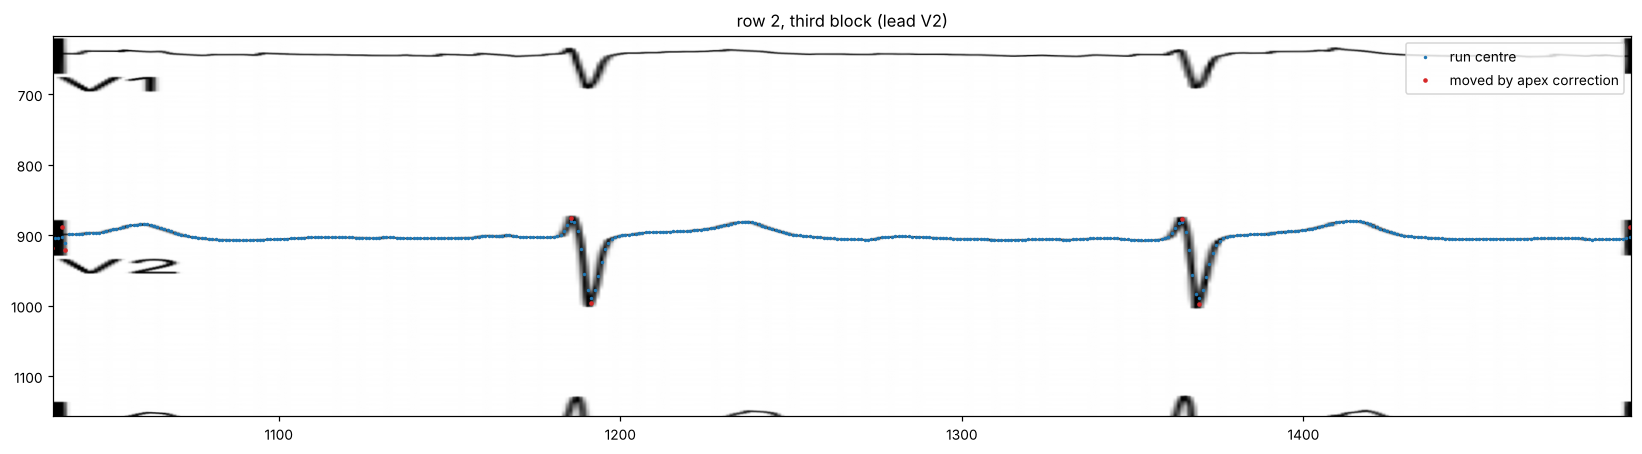

In [14]:
if BENCH is not None:
    r1, p1 = info['rows'][1], info['paths'][1]
    x_lo = int(info['x_start'] + 5 * 25 * info['ppm_x'])
    x_hi = x_lo + int(2.5 * 25 * info['ppm_x'])
    y_lo, y_hi = int(r1 - 40 * info['ppm_y']), int(r1 + 35 * info['ppm_y'])
    fig, ax = plt.subplots(figsize=(15, 4.2))
    ax.imshow(info['ink'][y_lo:y_hi, x_lo:x_hi], cmap='gray_r', extent=(x_lo, x_hi, y_hi, y_lo), aspect='auto')
    xs = np.arange(len(p1)) + info['x0'] + 0.5
    adj = apex_adjust(p1, 1.5 * info['ppm_x'], 0.6)
    moved = np.abs(adj - p1[:, 2]) > 0.5
    ax.plot(xs, p1[:, 2], '.', ms=2.5, color='tab:blue', label='run centre')
    ax.plot(xs[moved], adj[moved], '.', ms=4, color='tab:red', label='moved by apex correction')
    ax.set_xlim(x_lo, x_hi); ax.set_ylim(y_hi, y_lo); ax.legend(loc='upper right'); ax.set_title('row 2, third block (lead V2)')
    plt.tight_layout(); plt.show()

Digitised signal against the truth for four leads of the same image. The truth is shifted by the best lag and offset, as in the metric.

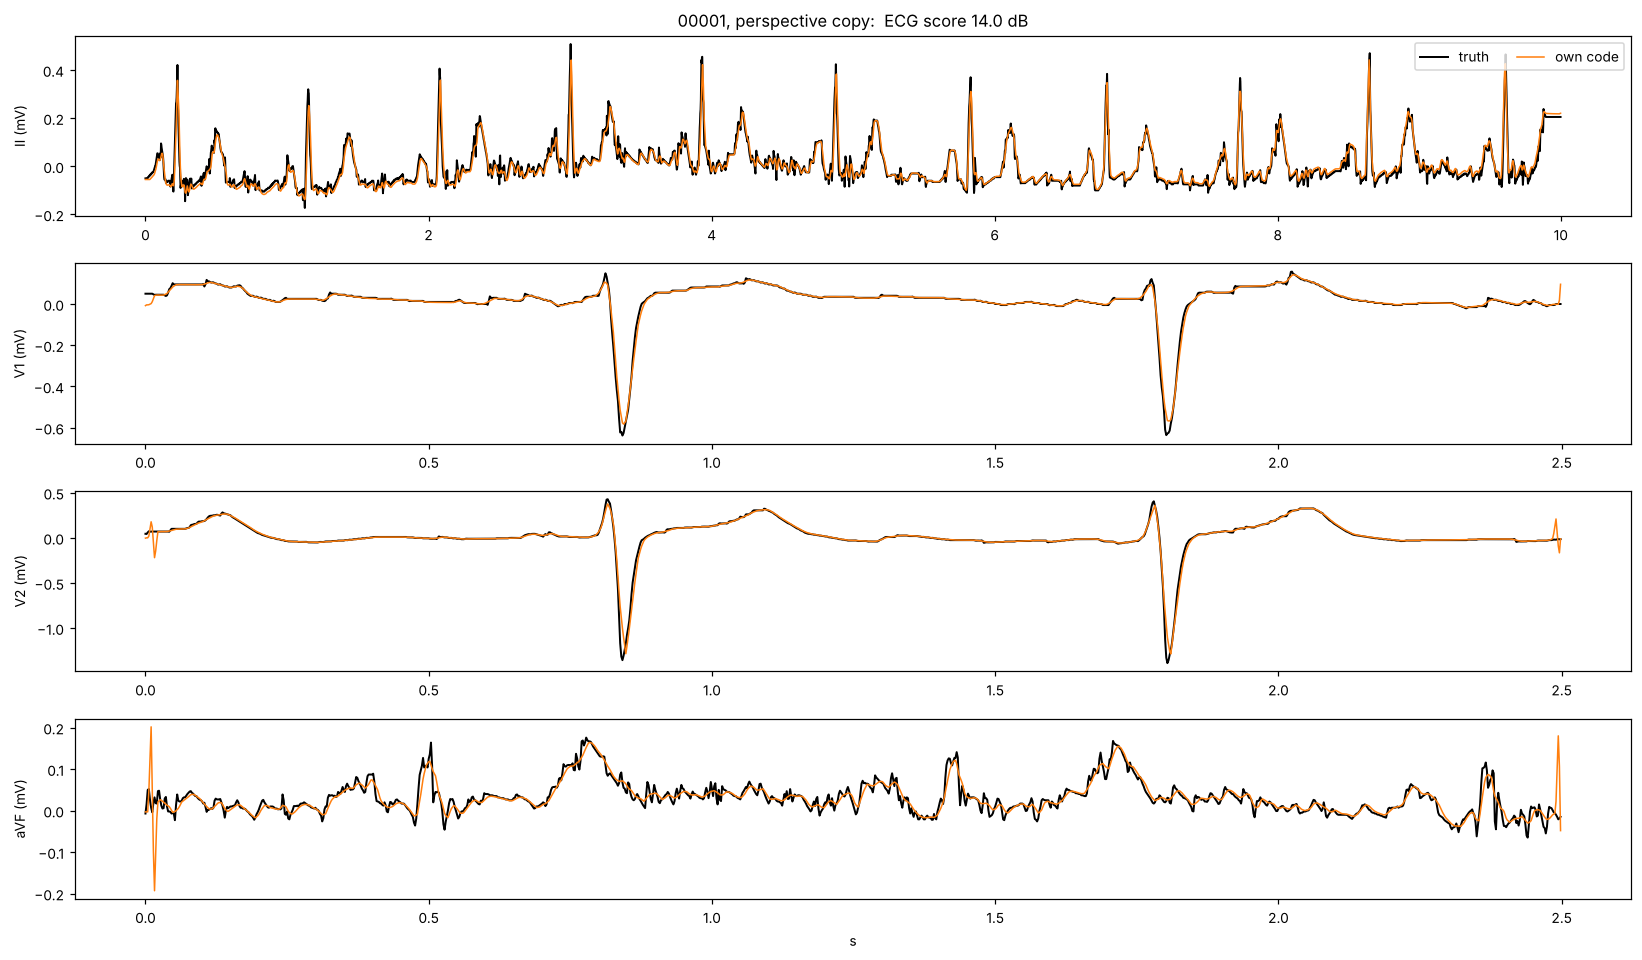

In [15]:
if BENCH is not None:
    def plot_leads(img, truth, n_rows, fs, leads_to_plot=('II', 'V1', 'V2', 'aVF'), title=''):
        series, err = digitize_safe(img, n_rows['II'])
        pred = split_leads(series, n_rows)
        score = snr_ecg(truth, pred, fs)
        fig, axes = plt.subplots(len(leads_to_plot), 1, figsize=(15, 2.2 * len(leads_to_plot)))
        for a, k in zip(np.atleast_1d(axes), leads_to_plot):
            t, p = truth[k], pred[k]
            a.plot(np.arange(len(t)) / fs, t, 'k', lw=1.3, label='truth')
            a.plot(np.arange(len(p)) / fs, p - np.mean(p - t), color='tab:orange', lw=1, label='own code')
            a.set_ylabel(f'{k} (mV)')
        np.atleast_1d(axes)[0].legend(loc='upper right', ncol=2)
        np.atleast_1d(axes)[0].set_title(f'{title}  ECG score {score:.1f} dB')
        np.atleast_1d(axes)[-1].set_xlabel('s')
        plt.tight_layout(); plt.show()

    plot_leads(img, truth, n_rows, fs, title='00001, perspective copy:')

## Scores on the benchmark

Every image goes through `digitize_safe`. The table shows mean, lowest and highest score in dB per set and variant.

In [16]:
if BENCH is not None:
    def run_benchmark(items, **flags):
        rows, preds = [], {}
        for name, rec, variant, subset in items:
            img, truth, n_rows, fs = load_item(rec, variant)
            t0 = time.time()
            series, err = digitize_safe(img, n_rows['II'], **flags)
            pred = split_leads(series, n_rows)
            rows.append(dict(name=name, record=rec, variant=variant, subset=subset,
                             snr_db=snr_ecg(truth, pred, fs), seconds=time.time() - t0, error=err))
            preds[name] = (truth, pred, fs)
        return pd.DataFrame(rows), preds


    own, own_preds = run_benchmark(MANIFEST)
    print('failures:', int(own['error'].notna().sum()), 'of', len(own))
    order = ['clean', 'tilt4', 'persp', 'degraded', 'rot90', 'rot180']
    summary = (own.groupby(['subset', 'variant'])['snr_db'].agg(['count', 'mean', 'min', 'max'])
               .reindex(pd.MultiIndex.from_product([['dev', 'held'], order]).intersection(
                   own.groupby(['subset', 'variant']).size().index)).round(2))
    display(summary)
    print(f"seconds per image: {own['seconds'].mean():.1f} (one CPU core)")

failures: 0 of 48


count   mean    min    max
dev  clean         8  15.73  10.58  18.86
     tilt4         4  13.45   8.51  15.28
     persp         4  13.12   8.80  15.35
     degraded      4  10.64   6.59  13.65
     rot90         4  13.83  10.58  16.25
     rot180        4  13.83  10.58  16.25
held clean         8  16.10  14.51  18.04
     tilt4         4  14.70  14.05  15.31
     persp         4  13.80  12.44  14.80
     degraded      4  11.56   7.95  13.32

seconds per image: 1.4 (one CPU core)


Scores per image: development set on the left, held-out set on the right.

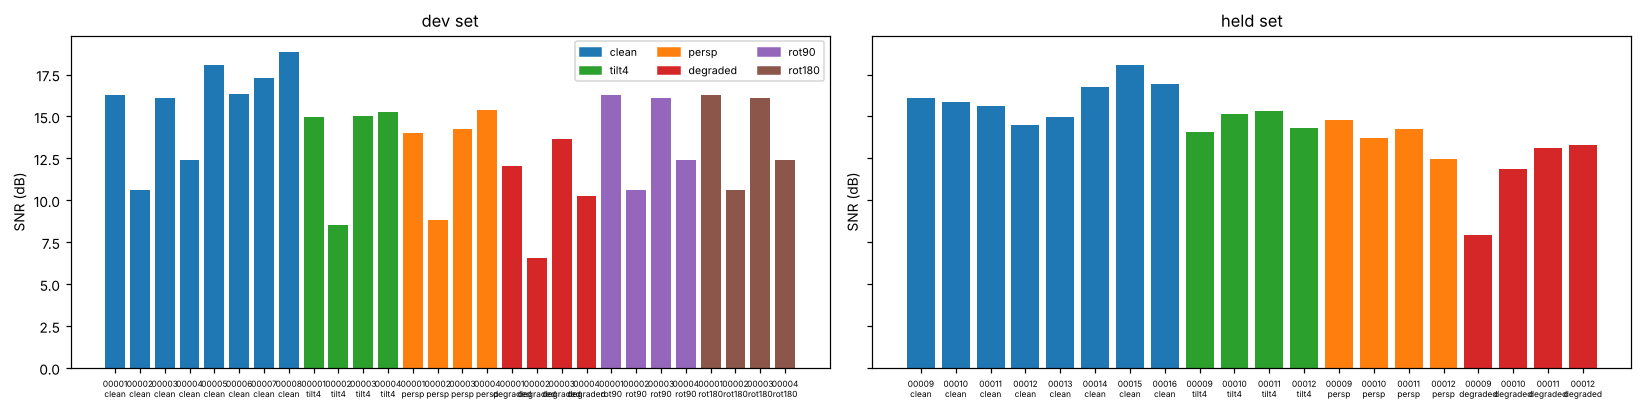

In [17]:
if BENCH is not None:
    fig, ax = plt.subplots(1, 2, figsize=(15, 3.8), sharey=True)
    for a, subset in zip(ax, ('dev', 'held')):
        d = own[own['subset'] == subset]
        names = [n for n in d['name']]
        cols = {'clean': 'tab:blue', 'tilt4': 'tab:green', 'persp': 'tab:orange', 'degraded': 'tab:red',
                'rot90': 'tab:purple', 'rot180': 'tab:brown'}
        a.bar(range(len(d)), d['snr_db'], color=[cols[v] for v in d['variant']])
        a.set_xticks(range(len(d))); a.set_xticklabels([n.replace('_', '\n') for n in names], fontsize=5.5)
        a.set_title(f'{subset} set'); a.set_ylabel('SNR (dB)')
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in cols.values()]
    ax[0].legend(handles, cols.keys(), ncol=3, fontsize=7)
    plt.tight_layout(); plt.show()

## Where the error comes from

The first table shows the share of the total error power per lead on the clean development images. The second splits the error by place: the first and last 20 samples of every lead block (boundaries), the steepest 5 % of the samples (QRS strokes), and the rest.

In [18]:
if BENCH is not None:
    def aligned(t, p, fs, max_shift_s=0.2):
        n = min(len(t), len(p)); t, p = np.nan_to_num(t[:n]), p[:n]
        ms, best, lag_best = int(round(max_shift_s * fs)), -np.inf, 0
        for lag in range(-ms, ms + 1):
            a0, a1 = max(0, lag), min(n, n + lag)
            c = np.dot(t[a0:a1] - t[a0:a1].mean(), p[a0 - lag:a1 - lag] - p[a0 - lag:a1 - lag].mean())
            if c > best: best, lag_best = c, lag
        a0, a1 = max(0, lag_best), min(n, n + lag_best)
        tt, pp = t[a0:a1], p[a0 - lag_best:a1 - lag_best]
        return a0, tt, pp + np.mean(tt - pp)


    lead_noise = {k: 0.0 for k in LEADS}
    where = dict(boundary=0.0, steep=0.0, other=0.0)
    counts = dict(boundary=0, steep=0, other=0)
    total, n_samples = 0.0, 0
    for name, (truth, pred, fs) in own_preds.items():
        if not name.endswith('_clean') or name[:5] not in DEV:
            continue
        for k in LEADS:
            a0, tt, pp = aligned(truth[k], pred[k], fs)
            e = (tt - pp) ** 2
            lead_noise[k] += e.sum(); total += e.sum()
            pos = (np.arange(a0, a0 + len(tt))) % 1250
            edge = (pos < 20) | (pos > 1229)
            steep = np.abs(np.gradient(tt)) > np.percentile(np.abs(np.gradient(tt)), 95)
            where['boundary'] += e[edge].sum(); where['steep'] += e[steep & ~edge].sum(); where['other'] += e[~edge & ~steep].sum()
            counts['boundary'] += int(edge.sum()); counts['steep'] += int((steep & ~edge).sum()); counts['other'] += int((~edge & ~steep).sum())
            n_samples += len(tt)

    share = pd.Series(lead_noise).sort_values(ascending=False) / total * 100
    print('share of the error power per lead (%), clean development images')
    display(share.round(1).to_frame('share %').T)
    print('share of the error power by place (%):', {k: round(v / total * 100) for k, v in where.items()})
    print('share of the samples in these places (%):', {k: round(v / n_samples * 100) for k, v in counts.items()})

    rows = []
    for name, (truth, pred, fs) in own_preds.items():
        if not name.endswith('_clean'):
            continue
        errs = {}
        for k in LEADS:
            a0, tt, pp = aligned(truth[k], pred[k], fs)
            errs[k] = ((tt - pp) ** 2).sum()
        top = sorted(errs, key=errs.get, reverse=True)[:2]
        rows.append(dict(image=name, score_db=own.set_index('name').loc[name, 'snr_db'], worst_two_leads=' + '.join(top),
                         share_of_error_pct=100 * sum(errs[k] for k in top) / sum(errs.values())))
    print('the two leads with the largest error in each clean image')
    display(pd.DataFrame(rows).round(1).set_index('image'))

share of the error power per lead (%), clean development images


,V4,V3,V2,II,V5,V6,V1,aVF,III,I,aVL,aVR
share %,38.1,19.5,17.1,6.5,4.7,2.8,2.6,2.2,1.8,1.6,1.5,1.4


share of the error power by place (%): {'boundary': 30, 'steep': 44, 'other': 26}
share of the samples in these places (%): {'boundary': 3, 'steep': 5, 'other': 92}


the two leads with the largest error in each clean image


,score_db,worst_two_leads,share_of_error_pct
image,,,
00001_clean,16.2,II + I,29.5
00002_clean,10.6,V3 + V2,81.6
00003_clean,16.1,V3 + II,28.9
00004_clean,12.4,V4 + II,85.1
00005_clean,18.1,II + V2,36.9
00006_clean,16.4,V2 + II,35.6
00007_clean,17.3,I + III,29.1
00008_clean,18.9,V3 + V2,43.7
00009_clean,16.1,V2 + V3,66.4


## Ablations

Each row switches one step off and re-scores the 20 development images that exist as clean (records 1 to 8), tilt4, persp and degraded (records 1 to 4 each). `no apex correction` sets the spike correction to zero, `no perspective step` skips `rectify_page`, `no tilt step` skips the rotation, `lead ticks removed` is the experiment above.

In [19]:
if BENCH is not None:
    subset_items = [m for m in MANIFEST if m[3] == 'dev' and m[2] in ('clean', 'tilt4', 'persp', 'degraded')]
    configs = {'full pipeline': {}, 'no apex correction': dict(apex_frac=0.0), 'no perspective step': dict(rectify=False),
               'no tilt step': dict(tilt=False), 'lead ticks removed': dict(bars=True)}
    table = {}
    for label, flags in configs.items():
        res, _ = run_benchmark(subset_items, **flags)
        table[label] = res.groupby('variant')['snr_db'].mean().reindex(['clean', 'tilt4', 'persp', 'degraded']).tolist() + [res['snr_db'].mean()]
    ablation = pd.DataFrame(table, index=['clean', 'tilt4', 'persp', 'degraded', 'mean of 20']).T.round(2)
    ablation['change vs full'] = (ablation['mean of 20'] - ablation.loc['full pipeline', 'mean of 20']).round(2)
    display(ablation)

,clean,tilt4,persp,degraded,mean of 20,change vs full
full pipeline,15.73,13.45,13.12,10.64,13.74,0.00
no apex correction,15.11,13.42,13.05,10.48,13.43,-0.31
no perspective step,15.73,12.86,0.79,10.64,11.15,-2.59
no tilt step,15.73,0.70,13.12,10.64,11.18,-2.56
lead ticks removed,15.52,13.61,13.08,10.72,13.69,-0.05


## Different image sizes

Competition images do not all have the size of the renders (2200 px wide, 7.9 px per mm). Maps with fewer than 6.5 px per mm are enlarged to about 7.9 px per mm before the page is analysed, and the first analysis steps work at a fixed scale. Test: held-out records 00009 to 00012, clean, resized to other widths. Nothing was tuned on this table.

In [20]:
if BENCH is not None:
    sizes = []
    for scale in (0.4, 0.5, 0.75, 1.0, 1.5):
        for rec in HELD[:4]:
            img, truth, n_rows, fs = load_item(rec, 'clean')
            img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC)
            series, err = digitize_safe(img, n_rows['II'])
            sizes.append(dict(scale=scale, width_px=img.shape[1], px_per_mm=round(7.874 * scale, 1), record=rec,
                              snr_db=snr_ecg(truth, split_leads(series, n_rows), fs)))
    sizes = pd.DataFrame(sizes)
    display(sizes.groupby(['scale', 'width_px', 'px_per_mm'])['snr_db'].agg(['mean', 'min', 'max']).round(2))

,,,mean,min,max
scale,width_px,px_per_mm,,,
0.40,880,3.1,9.98,5.74,12.93
0.50,1100,3.9,13.99,13.19,14.67
0.75,1650,5.9,14.21,11.63,15.10
1.00,2200,7.9,15.51,14.51,16.11
1.50,3300,11.8,16.93,15.36,19.18


## Comparison with the submitted pipeline

`benchmark/reference_final_pipeline_level3.csv` holds the scores of the submitted notebook's pipeline on the same images, measured with the same metric. They were computed outside this notebook (the pretrained weights are needed) with the cheapest setting: stage 0 and 1 of hengck23 plus **one** of the six stage 2 models of Takashi Someya (`b6a`), no flip averaging, on a CPU. The submitted notebook ensembles six models with flip averaging, so this reference is a lower bound for it.

In [21]:
if BENCH is not None:
    ref = pd.read_csv(BENCH / 'reference_final_pipeline_level3.csv')[['name', 'snr_db', 'route']].rename(columns={'snr_db': 'pretrained_db'})
    cmp = own.merge(ref, on='name', how='inner').rename(columns={'snr_db': 'own_db'})
    cmp['gap_db'] = cmp['pretrained_db'] - cmp['own_db']
    print(f'{len(cmp)} of {len(own)} benchmark images have a reference score')
    g = (cmp.groupby(['subset', 'variant'])[['own_db', 'pretrained_db', 'gap_db']].mean().round(2))
    g.insert(0, 'n', cmp.groupby(['subset', 'variant']).size())
    display(g.reindex(pd.MultiIndex.from_product([['dev', 'held'], order]).intersection(g.index)))
    allm = cmp[['own_db', 'pretrained_db', 'gap_db']].mean().round(2)
    print(f"all {len(cmp)} images: own {allm['own_db']} dB, pretrained {allm['pretrained_db']} dB, gap {allm['gap_db']} dB")
    clean = cmp[cmp['variant'] == 'clean']
    print(f"clean images ({len(clean)}): own {clean['own_db'].mean():.2f} dB, pretrained {clean['pretrained_db'].mean():.2f} dB, "
          f"gap {clean['gap_db'].mean():.2f} dB, pretrained better on {(clean['gap_db'] > 0).sum()} of {len(clean)}")
    for subset in ('dev', 'held'):
        d = clean[clean['subset'] == subset]
        if len(d):
            print(f"  {subset} clean ({len(d)}): own {d['own_db'].mean():.2f} dB, pretrained {d['pretrained_db'].mean():.2f} dB, gap {d['gap_db'].mean():.2f} dB")

48 of 48 benchmark images have a reference score


n  own_db  pretrained_db  gap_db
dev  clean     8   15.73          28.89   13.16
     tilt4     4   13.45          24.13   10.68
     persp     4   13.12          24.22   11.10
     degraded  4   10.64          21.19   10.55
     rot90     4   13.83          25.40   11.57
     rot180    4   13.83          25.01   11.19
held clean     8   16.10          31.27   15.17
     tilt4     4   14.70          29.38   14.69
     persp     4   13.80          28.26   14.46
     degraded  4   11.56          24.64   13.08

all 48 images: own 14.05 dB, pretrained 26.88 dB, gap 12.83 dB
clean images (16): own 15.92 dB, pretrained 30.08 dB, gap 14.16 dB, pretrained better on 16 of 16
  dev clean (8): own 15.73 dB, pretrained 28.89 dB, gap 13.16 dB
  held clean (8): own 16.10 dB, pretrained 31.27 dB, gap 15.17 dB


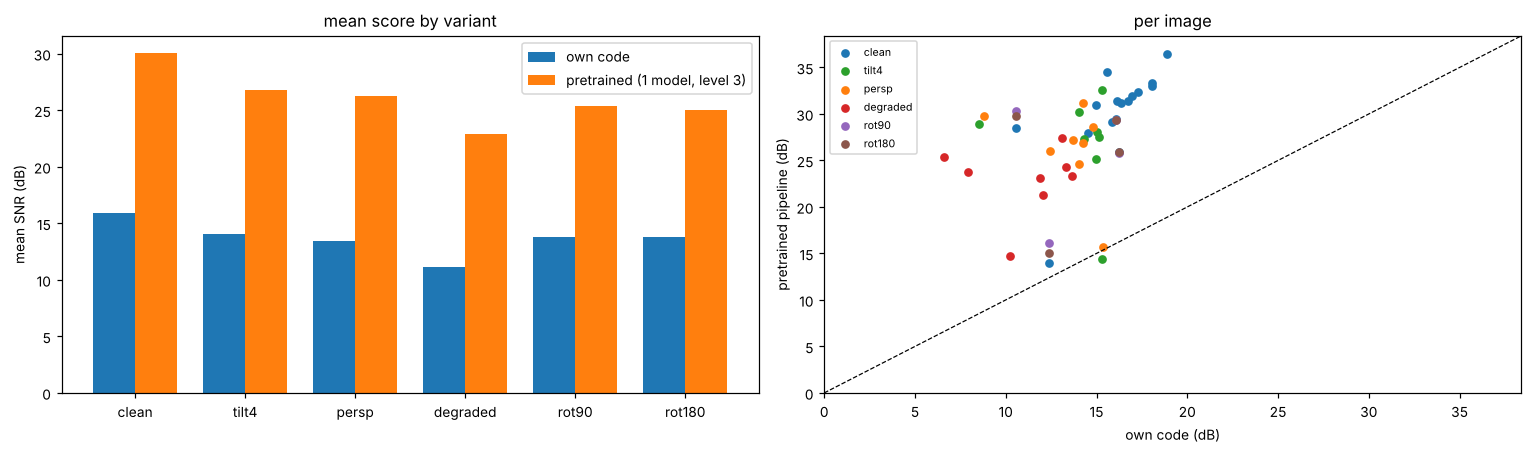

In [22]:
if BENCH is not None:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
    vs = [v for v in order if v in set(cmp['variant'])]
    w = 0.38
    ax[0].bar(np.arange(len(vs)) - w / 2, [cmp[cmp.variant == v]['own_db'].mean() for v in vs], w, label='own code')
    ax[0].bar(np.arange(len(vs)) + w / 2, [cmp[cmp.variant == v]['pretrained_db'].mean() for v in vs], w, label='pretrained (1 model, level 3)')
    ax[0].set_xticks(range(len(vs))); ax[0].set_xticklabels(vs); ax[0].set_ylabel('mean SNR (dB)'); ax[0].legend(); ax[0].set_title('mean score by variant')
    cols = {'clean': 'tab:blue', 'tilt4': 'tab:green', 'persp': 'tab:orange', 'degraded': 'tab:red', 'rot90': 'tab:purple', 'rot180': 'tab:brown'}
    for v in vs:
        d = cmp[cmp.variant == v]
        ax[1].scatter(d['own_db'], d['pretrained_db'], s=22, color=cols[v], label=v)
    lim = [0, max(cmp['pretrained_db'].max(), cmp['own_db'].max()) + 2]
    ax[1].plot(lim, lim, 'k--', lw=0.8); ax[1].set_xlim(lim); ax[1].set_ylim(lim)
    ax[1].set_xlabel('own code (dB)'); ax[1].set_ylabel('pretrained pipeline (dB)'); ax[1].legend(fontsize=7); ax[1].set_title('per image')
    plt.tight_layout(); plt.show()

The first table lists the five images with the largest gap, the second the five with the smallest. The gap is smallest on record 00004, which is hard for both methods. It is largest on 00002 and 00011, where two leads carry most of the own-code error (V3 and V2 in 00002, V2 and V1 in 00011, see the per-image table above). A likely cause is strokes of several leads merging into one vertical line, but this was not checked image by image. On the easiest images the own pipeline levels off far below the pretrained network. That is probably the precision of the run-centre approach (line width, two or three samples per pixel column, glitches at the lead ticks), which was not tested.

In [23]:
if BENCH is not None:
    display(cmp.sort_values('gap_db', ascending=False)[['name', 'own_db', 'pretrained_db', 'gap_db']].head(5).round(2))
    display(cmp.sort_values('gap_db')[['name', 'own_db', 'pretrained_db', 'gap_db']].head(5).round(2))

,name,own_db,pretrained_db,gap_db
13,00002_persp,8.80,29.73,20.93
9,00002_tilt4,8.51,28.90,20.38
21,00002_rot90,10.58,30.29,19.71
25,00002_rot180,10.58,29.76,19.17
30,00011_clean,15.59,34.55,18.95


,name,own_db,pretrained_db,gap_db
11,00004_tilt4,15.28,14.43,-0.85
15,00004_persp,15.35,15.74,0.39
3,00004_clean,12.40,14.02,1.62
27,00004_rot180,12.40,15.06,2.65
23,00004_rot90,12.40,16.12,3.72


In [24]:
if BENCH is not None:
    try:
        own.drop(columns=['error']).round({'snr_db': 3, 'seconds': 2}).to_csv(BENCH / 'own_code_results.csv', index=False)
        ablation.to_csv(BENCH / 'own_code_ablation.csv')
        sizes.groupby(['scale', 'width_px', 'px_per_mm'])['snr_db'].agg(['mean', 'min', 'max']).round(3).to_csv(BENCH / 'own_code_sizes.csv')
        print('saved own_code_results.csv, own_code_ablation.csv, own_code_sizes.csv in', BENCH)
    except OSError as exc:
        print('results not saved:', exc)

saved own_code_results.csv, own_code_ablation.csv, own_code_sizes.csv in ../benchmark


## Competition data (only when attached)

This part needs the competition data as a Kaggle input.

1. **Check on training ECGs.** A few training ECGs with known ground truth are digitised and scored with `snr_ecg`.
2. **Submission.** All test images are digitised on several CPU processes and written to `submission.csv` in the format of `sample_submission.parquet`. A failed or unreadable image gets zeros.

Without the competition data the cells print a note and stop.

In [25]:
def read_truth(csv_path):
    """Ground truth of a training ECG: lead -> signal and the row counts in the test.csv convention."""
    df = pd.read_csv(csv_path)
    truth = {}
    for lead in LEADS:
        v = df[lead].to_numpy(dtype=float)
        truth[lead] = v if lead == 'II' else v[~np.isnan(v)]       # short leads are NaN outside their 2.5 s block
    return truth, {k: len(v) for k, v in truth.items()}


def check_on_training(n_ecg, per_ecg):
    ids = pd.read_csv(COMP / 'train.csv', dtype=str, nrows=max(n_ecg * 5, 50)).iloc[:, 0].tolist()
    rows = []
    for cid in ids:
        folder = COMP / 'train' / cid
        truth_file = folder / f'{cid}.csv'
        images = sorted(folder.glob(f'{cid}-*.png'))[:per_ecg] if folder.is_dir() else []
        if not truth_file.exists() or not images:
            continue
        truth, n_rows = read_truth(truth_file)
        fs = len(truth['II']) / STRIP_SECONDS
        for path in images:
            t0 = time.time()
            series, err = digitize_safe(read_rgb(path), n_rows['II'])
            rows.append(dict(ecg=cid, image=path.name, snr_db=snr_ecg(truth, split_leads(series, n_rows), fs),
                             seconds=time.time() - t0, error=err))
        if len({r['ecg'] for r in rows}) >= n_ecg:
            break
    return pd.DataFrame(rows)


if COMP is None:
    print('Competition data not attached: this section is skipped.')
else:
    try:
        chk = check_on_training(CONFIG['n_check'], CONFIG['images_per_check'])
    except Exception as exc:                      # the check is optional, it must not stop the submission below
        chk = pd.DataFrame()
        print('check on training ECGs failed:', repr(exc))
    if len(chk):
        display(chk.round(2).head(12))
        print(f"{len(chk)} images of {chk['ecg'].nunique()} training ECGs: mean {chk['snr_db'].mean():.2f} dB, "
              f"median {chk['snr_db'].median():.2f} dB, failures {int(chk['error'].notna().sum())}")
    else:
        print('no training ECGs with images and ground truth found')

Competition data not attached: this section is skipped.


In [26]:
def digitize_file(args):
    ecg, path, length = args
    try:
        img = read_rgb(path)
    except Exception as exc:                      # unreadable file: zeros, like any other failed image
        return ecg, np.zeros((4, length), np.float32), f'read error: {exc}'
    series, err = digitize_safe(img, length)
    return ecg, np.clip(np.nan_to_num(series), -10, 10), err


def run_submission(path):
    import multiprocessing as mp
    test = pd.read_csv(COMP / 'test.csv', dtype={'id': str})
    layout = {k: [(lead, int(n)) for lead, n in zip(g['lead'], g['number_of_rows'])] for k, g in test.groupby('id', sort=False)}
    ids = list(layout)
    jobs = [(i, str(COMP / 'test' / f'{i}.png'), dict(layout[i])['II']) for i in ids]
    failed, written, t0 = [], 0, time.time()
    pool = mp.get_context('fork').Pool(CONFIG['workers']) if CONFIG['workers'] > 1 else None
    results = pool.imap(digitize_file, jobs, chunksize=4) if pool else map(digitize_file, jobs)
    tmp = str(path) + '.tmp'
    with open(tmp, 'w') as f:
        f.write('id,value\n')
        for k, (ecg, series, err) in enumerate(results):
            if err:
                failed.append((ecg, err))
            leads = split_leads(series, dict(layout[ecg]))
            for lead, n in layout[ecg]:
                f.write('\n'.join(f'{ecg}_{i}_{lead},{v:.5f}' for i, v in enumerate(leads[lead].tolist())) + '\n')
                written += n
            if k and k % 100 == 0:
                print(f'{k}/{len(ids)} ECGs, {time.time() - t0:.0f} s')
    if pool:
        pool.close(); pool.join()
    os.replace(tmp, path)
    print(f'{len(ids)} ECGs, {written:,} rows, {time.time() - t0:.0f} s, {len(failed)} failed (filled with zeros)')
    return failed, written


def check_against_sample(path, n_written):
    import pyarrow.parquet as pq
    from itertools import islice
    pf = pq.ParquetFile(COMP / 'sample_submission.parquet')
    if pf.metadata.num_rows != n_written:
        raise ValueError(f'row count differs: submission {n_written:,}, sample {pf.metadata.num_rows:,}')
    different = 0
    with open(path) as f:
        next(f)
        for batch in pf.iter_batches(batch_size=500_000, columns=['id']):
            expected = batch.column('id').to_pylist()
            got = [line.split(',', 1)[0] for line in islice(f, len(expected))]
            different += sum(a != b for a, b in zip(expected, got))
    if different:
        raise ValueError(f'{different:,} ids differ from sample_submission.parquet')
    print('ids and row count match sample_submission.parquet')


if COMP is None:
    print('Competition data not attached: no submission written.')
else:
    failed, n_written = run_submission(CONFIG['submission_path'])
    if (COMP / 'sample_submission.parquet').exists():
        check_against_sample(CONFIG['submission_path'], n_written)
    for ecg, err in failed[:5]:
        print('failed:', ecg, err)

Competition data not attached: no submission written.


## Summary

**Kaggle result.** Run on Kaggle with only the competition data attached, this notebook scored **21.15672** on the public leaderboard (submitted after the deadline). The submitted notebook with the pretrained models scored 23.38235 public and 23.27202 private, so the pretrained models add about 2.2 dB.

**Benchmark vs Kaggle.** On the local benchmark the gap is much larger: over all 48 images the own code scores about 14 dB and the pretrained pipeline, at its cheapest setting, about 27 dB. I did not find out why the benchmark gap is so much bigger than the Kaggle gap. The benchmark is 16 ECGs drawn with one tool, so it does not predict the leaderboard score.

**Limits of the benchmark**

- The images are clean renders plus five distortions chosen by hand. Real images also have creases, stains, shadows, handwriting and other paper types.
- Thresholds and the apex factor were set on the development set. The held-out scores are in line with the development scores.
- The reference scores come from one stage 2 model, the submitted notebook uses six.
- The mean of per-image dB values is used throughout. The competition's own averaging may differ in detail.

**Limits of the own-code pipeline.** It needs a coloured grid (no grid, no scale), assumes the standard 3 x 4 layout with the 10 s rhythm strip and 25 mm/s, 10 mm/mV, handles perspective only when the page corners are visible, does not handle curled or creased paper, and where the strokes of several leads merge into one vertical line it cannot tell the leads apart.